In [7]:
import json
import random
from pathlib import Path
import pandas as pd
import sys
from IPython.display import Image, display

# ---- Project root setup ----

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

# ---- Set plan filename ----

plan_filename = "static_plan.json"
plan_lib = json.loads((PROJECT_ROOT / "planner" / plan_filename).read_text())

In [2]:
# ---- 0) Validate entire JSON library (optional) ----

from runner.validate_plan import validate_plan_library

validate_plan_library(plan_lib)
print("✅ Plan library validated")

✅ Plan library validated


In [3]:
# ---- 1) Read JSON run library ----

runs = plan_lib["runs"]
run_idx = random.randrange(len(runs))  # safe random index
# run_idx = 0                          # set index manually
run_plan = runs[run_idx]

print(f"Selected run_idx={run_idx}, run_id={run_plan.get('run_id')}")
print("request_text:", run_plan.get("request_text"))
print("jobs:", [j.get("job_id") for j in run_plan.get("jobs", [])])

Selected run_idx=2, run_id=demo_arm_vibration
request_text: The ARM technician will be out next week. Are any vibration PMs coming up?
jobs: ['arm_fleet_vibration_health_check']


In [4]:
# ---- 1.5) Schema validation ----

from runner.validate_plan import validate_run_plan, PlanValidationError

try:
    validate_run_plan(run_plan)
except PlanValidationError as e:
    print("Plan validation failed:", e)
    raise

In [5]:
# ---- 2) Execute one run ----

from runner.run_one_run import run_one_run

run_dir = run_one_run(run_plan, PROJECT_ROOT)
print("Run directory:", run_dir)


Run directory: /Users/mcmoore/anaconda_projects/GitHub/agentic-predictive-maintenance/runs/2026-02-26T11-00-32



--- Job: arm_fleet_vibration_health_check ---
Plot: /Users/mcmoore/anaconda_projects/GitHub/agentic-predictive-maintenance/runs/2026-02-26T11-00-32/arm_fleet_vibration_health_check/arm_fleet_vibration_time_trend.png


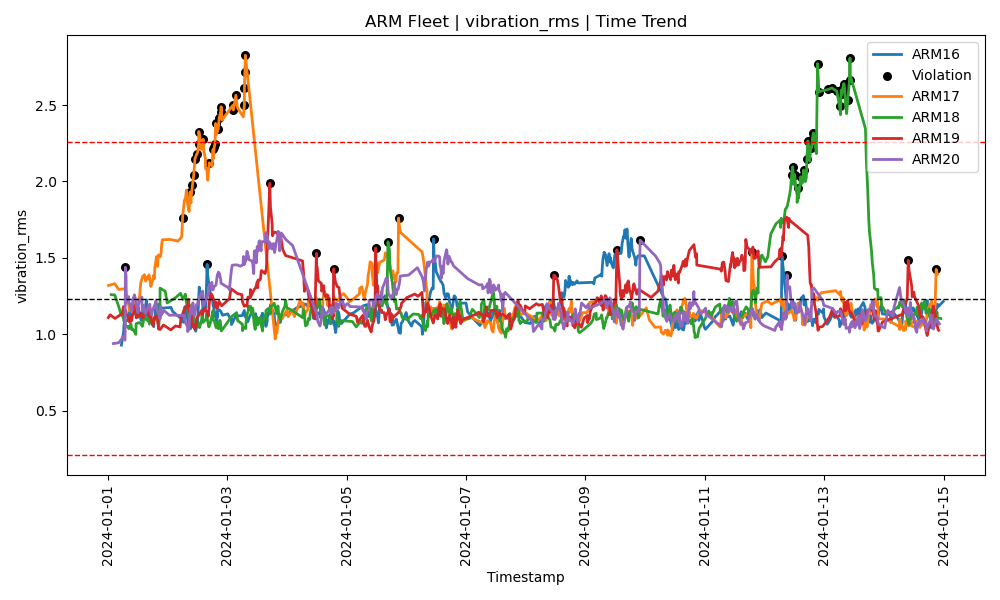

Plot: /Users/mcmoore/anaconda_projects/GitHub/agentic-predictive-maintenance/runs/2026-02-26T11-00-32/arm_fleet_vibration_health_check/arm_fleet_vibration_boxplot.png


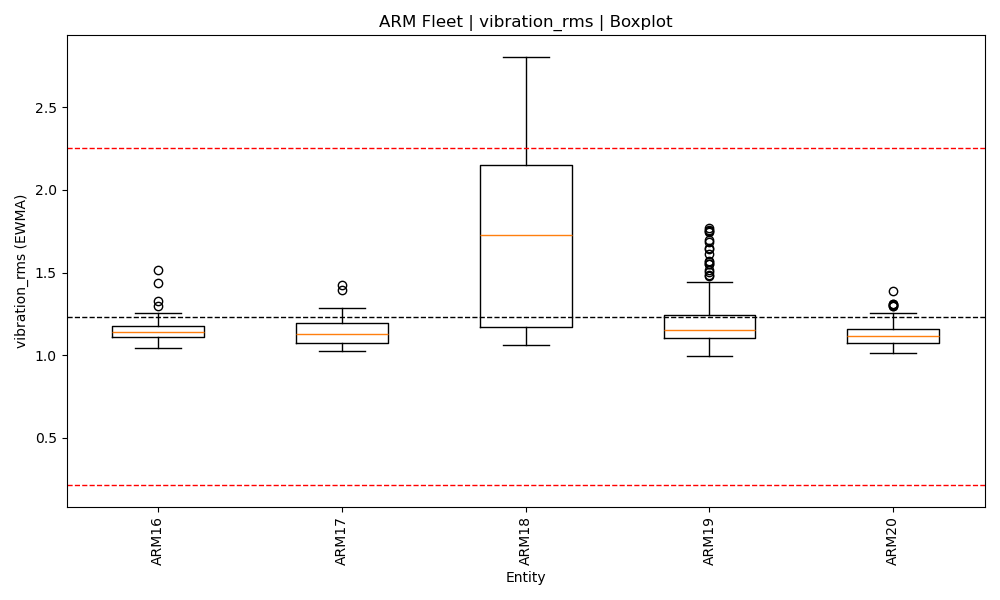

Table: /Users/mcmoore/anaconda_projects/GitHub/agentic-predictive-maintenance/runs/2026-02-26T11-00-32/arm_fleet_vibration_health_check/arm_fleet_vibration_OOCs_last_1_day.csv


,entity_group,sensor,entity,total_points,ooc_points,percent_ooc
0,ARM,vibration_rms,ARM16,43.0,0.0,0.000000
1,ARM,vibration_rms,ARM17,42.0,1.0,2.380952
2,ARM,vibration_rms,ARM18,39.0,0.0,0.000000
3,ARM,vibration_rms,ARM19,35.0,1.0,2.857143
4,ARM,vibration_rms,ARM20,46.0,0.0,0.000000


In [8]:
# ---- 3) Display Artifacts ----
for job in run_plan.get("jobs", []):
    job_id = job["job_id"]
    job_dir = run_dir / job_id

    print("\n--- Job:", job_id, "---")

    outputs = job.get("outputs", {})

    # Display Plots
    for plot_spec in outputs.get("plots", []):
        plot_name = plot_spec["plot_name"]
        plot_path = job_dir / plot_name

        print("Plot:", plot_path)

        if plot_path.exists():
            display(Image(filename=str(plot_path)))
        else:
            print("  (missing plot file)")

    # Display Tables
    for table_spec in outputs.get("tables", []):
        table_name = table_spec["table_name"]
        table_path = job_dir / table_name

        print("Table:", table_path)

        if table_path.exists():
            try:
                df_table = pd.read_csv(table_path)
                display(df_table)
            except Exception as e:
                print(f"  (failed to read table: {e})")
        else:
            print("  (missing table file)")